# Analyse et Détection des Valeurs Aberrantes (Outliers) de Taille de Groupe

Ce notebook permet d'analyser les jeux de données d'observations (fichiers de points) pour y détecter et afficher les valeurs aberrantes (outliers) concernant la taille des groupes.

### Règle de sélection du champ :
- Si le jeu de données contient le champ **`individual_count`**, il est utilisé en priorité.
- Sinon, le champ **`size_group`** (ou son alias standard **`group_size`**) est utilisé.

### Prise en charge des plages de valeurs (ex: "4-10") :
- Les valeurs sous forme de plage de type `"4-10"` ou `"5 to 15"` sont automatiquement analysées.
- La moyenne de la plage est calculée et arrondie à l'entier supérieur le plus proche pour obtenir un nombre entier d'individus.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# Configuration des chemins
index_path = Path("index.csv")
data_dir_local = Path("data_source/data_sources_point")
data_dir_remote = Path("C:/MyPc/master/s4/stage-ird/dataset/baleine-seamap/data_source/data_sources_point")

# Style pour les graphiques
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

### 1. Chargement de l'index des données
Nous lisons le fichier `index.csv` pour identifier tous les jeux de données disponibles.

In [7]:
if index_path.exists():
    df_index = pd.read_csv(index_path)
    df_index.columns = df_index.columns.str.strip()
    print(f"Index chargé avec succès. Nombre total de datasets : {len(df_index)}")
    
    # Filtrer les datasets ayant un fichier point valide
    df_index['has_points_local'] = df_index['Dataset'].apply(lambda x: (data_dir_local / str(x).strip()).exists())
    df_index['has_points_remote'] = df_index['Dataset'].apply(lambda x: (data_dir_remote / str(x).strip()).exists())
    df_index['has_points'] = df_index['has_points_local'] | df_index['has_points_remote']
    
    df_points_only = df_index[df_index['has_points'] == True]
    print(f"Datasets avec fichiers de points disponibles : {len(df_points_only)}")
    
    print("\nExemple de datasets disponibles pour l'analyse :")
    display(df_points_only[['ID', 'Title', 'Dataset', 'Records']].head(10))
else:
    print("ERREUR : Le fichier index.csv n'a pas été trouvé à la racine du projet.")

Index chargé avec succès. Nombre total de datasets : 201
Datasets avec fichiers de points disponibles : 201

Exemple de datasets disponibles pour l'analyse :


,ID,Title,Dataset,Records
0,2378,Happywhale - Gray dolphin in South Pacific Ocean,obis_seamap_dataset_2378_points.csv,1
1,2377,Happywhale - Amazon river dolphin in South Pac...,obis_seamap_dataset_2377_points.csv,1
2,1747,Happywhale - Sei whale in South Atlantic Ocean,obis_seamap_dataset_1747_points.csv,133
3,1728,Happywhale - Sperm whale in South Atlantic Ocean,obis_seamap_dataset_1728_points.csv,21
4,1727,Happywhale - Sperm whale in North Pacific Ocean,obis_seamap_dataset_1727_points.csv,361
5,2153,Happywhale - Omurai's whale in Indian Ocean,obis_seamap_dataset_2153_points.csv,12
6,1726,Happywhale - Sperm whale in North Atlantic Ocean,obis_seamap_dataset_1726_points.csv,"7,68"
7,1762,Happywhale - Humpback whale in Arctic Ocean,obis_seamap_dataset_1762_points.csv,"10,53"
8,2084,Happywhale - Bryde's whale in North Atlantic O...,obis_seamap_dataset_2084_points.csv,49
9,1761,Happywhale - Blue whale in South Pacific Ocean,obis_seamap_dataset_1761_points.csv,54


### 2. Définition des fonctions de sélection de colonne et de détection des outliers pour un dataset individuel
Nous définissons d'abord les outils d'analyse unitaire pour étudier un jeu de données spécifique, y compris le parseur de plages de valeurs.

In [8]:
def parse_group_size_val(val):
    """
    Convertit une valeur de taille de groupe en nombre.
    Gère les plages de valeurs sous forme de chaîne (ex: "4-10", "4 - 10", "4/10", "4 to 10")
    en calculant la moyenne des deux bornes et en renvoyant un entier.
    """
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return val
        
    val_str = str(val).strip()
    if not val_str:
        return np.nan
        
    # Pattern pour les plages numériques (ex: "4-10", "4 - 10", "4/10")
    range_match = re.match(r'^(\d+(?:\.\d+)?)\s*[-/|]\s*(\d+(?:\.\d+)?)$', val_str)
    if not range_match:
        # Essai avec le format "4 to 10"
        range_match = re.match(r'^(\d+(?:\.\d+)?)\s+to\s+(\d+(?:\.\d+)?)$', val_str, re.IGNORECASE)
        
    if range_match:
        try:
            low = float(range_match.group(1))
            high = float(range_match.group(2))
            # Calculer la moyenne et arrondir à l'entier le plus proche
            return int(round((low + high) / 2.0))
        except ValueError:
            pass
            
    # Essai de conversion directe (ex: "15", "3.0")
    try:
        clean_str = val_str.replace(',', '')
        return float(clean_str)
    except ValueError:
        # Fallback : extraire le premier nombre trouvé si présent (ex: ">10" -> 10)
        numbers = re.findall(r'\d+(?:\.\d+)?', val_str)
        if numbers:
            try:
                return float(numbers[0])
            except ValueError:
                pass
        return np.nan

def get_group_size_column(df):
    """
    Détermine la colonne à utiliser pour la taille du groupe.
    Priorité : 
    1. individual_count
    2. size_group
    3. group_size (repli standard)
    """
    cols = [c.strip().lower() for c in df.columns]
    col_mapping = {c.strip().lower(): c for c in df.columns}
    
    if 'individual_count' in cols:
        target_col = col_mapping['individual_count']
        print(f"-> Champ 'individual_count' détecté et sélectionné : '{target_col}'")
        return target_col
    elif 'size_group' in cols:
        target_col = col_mapping['size_group']
        print(f"-> Champ 'size_group' détecté et sélectionné : '{target_col}'")
        return target_col
    elif 'group_size' in cols:
        target_col = col_mapping['group_size']
        print(f"-> Champ 'group_size' détecté et sélectionné : '{target_col}'")
        return target_col
    else:
        for c in cols:
            if 'count' in c or 'size' in c or 'abondance' in c:
                target_col = col_mapping[c]
                print(f"-> Champ alternatif détecté et sélectionné : '{target_col}'")
                return target_col
        print("-> Aucun champ de comptage ou de taille de groupe trouvé.")
        return None

def load_dataset(dataset_id_or_file):
    """
    Charge le dataset de points en local ou à distance et détecte la colonne cible.
    """
    file_name = str(dataset_id_or_file).strip()
    if not file_name.endswith('.csv'):
        row = df_index[df_index['ID'].astype(str).str.strip() == file_name]
        if not row.empty:
            file_name = row.iloc[0]['Dataset'].strip()
            title = row.iloc[0]['Title'].strip()
            print(f"Analyse du dataset ID {dataset_id_or_file} : '{title}'")
        else:
            file_name = f"obis_seamap_dataset_{dataset_id_or_file}_points.csv"
            print(f"Dataset ID {dataset_id_or_file} absent de l'index. Tentative avec : {file_name}")
            
    path = data_dir_local / file_name
    if not path.exists():
        path = data_dir_remote / file_name
        
    if not path.exists():
        print(f"Erreur : Le fichier de points '{file_name}' est introuvable.")
        return None, None
        
    df = pd.read_csv(path, low_memory=False)
    print(f"Fichier chargé avec succès : {path.name} ({len(df)} lignes)")
    
    col = get_group_size_column(df)
    return df, col

def detect_outliers(df, col):
    """
    Détecte les outliers statistiques et les anomalies biologiques.
    """
    if col is None or col not in df.columns:
        print("La colonne cible est introuvable.")
        return pd.DataFrame(), {}
        
    df_clean = df.copy()
    df_clean.columns = df_clean.columns.str.strip()
    # Application du parser robuste pour gérer les plages "4-10"
    df_clean['numeric_value'] = df_clean[col].apply(parse_group_size_val)
    
    df_valid = df_clean[df_clean['numeric_value'] >= 0].dropna(subset=['numeric_value']).copy()
    if df_valid.empty or len(df_valid) < 4:
        print("Données insuffisantes pour une détection statistique.")
        return pd.DataFrame(), {}
        
    Q1 = df_valid['numeric_value'].quantile(0.25)
    Q3 = df_valid['numeric_value'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    stats_bounds = {
        'min': df_valid['numeric_value'].min(),
        'Q1': Q1,
        'median': df_valid['numeric_value'].median(),
        'Q3': Q3,
        'max': df_valid['numeric_value'].max(),
        'IQR': IQR,
        'upper_bound': upper_bound
    }
    
    outliers_stat = df_valid[df_valid['numeric_value'] > upper_bound].copy()
    outliers_stat['Outlier_Type'] = 'Statistique (IQR)'
    outliers_stat['Reason'] = f"Supérieur au seuil statistique IQR ({upper_bound:.1f} individus)"
    
    anomalies_bio = []
    whales = {
        'megaptera novaeangliae', 'balaenoptera physalus', 'balaenoptera musculus',
        'balaenoptera acutorostrata', 'balaenoptera bonaerensis', 'balaenoptera borealis',
        'balaenoptera edeni', 'physeter macrocephalus', 'eubalaena glacialis',
        'eubalaena australis', 'eubalaena japonica', 'balaena mysticetus',
        'eschrichtius robustus'
    }
    
    for idx, row in df_clean.iterrows():
        val = row['numeric_value']
        if pd.isna(val):
            continue
            
        if val < 0:
            row_dict = row.to_dict()
            row_dict['Outlier_Type'] = 'Valeur Négative'
            row_dict['Reason'] = f'Valeur négative détectée ({val})'
            anomalies_bio.append(row_dict)
        elif val == 9999:
            row_dict = row.to_dict()
            row_dict['Outlier_Type'] = 'Placeholder 9999'
            row_dict['Reason'] = 'Code standard 9999 pour données inestimables ou manquantes'
            anomalies_bio.append(row_dict)
        elif val >= 50:
            sp_name = str(row.get('scientific_name', '')).strip().lower()
            if any(w in sp_name for w in whales):
                row_dict = row.to_dict()
                row_dict['Outlier_Type'] = 'Biologique (Baleine)'
                row_dict['Reason'] = f'Taille de groupe irréaliste pour un grand cétacé solitaire (>= 50)'
                anomalies_bio.append(row_dict)
            elif 'ursus' in sp_name and val > 10:
                row_dict = row.to_dict()
                row_dict['Outlier_Type'] = 'Biologique (Ours)'
                row_dict['Reason'] = 'Taille de groupe irréaliste pour des ours polaires solitaires (> 10)'
                anomalies_bio.append(row_dict)
            elif val >= 3000:
                row_dict = row.to_dict()
                row_dict['Outlier_Type'] = 'Biologique (Extrême)'
                row_dict['Reason'] = f'Effectif extrêmement massif (>= 3000 individus)'
                anomalies_bio.append(row_dict)
                
    df_anomalies_bio = pd.DataFrame(anomalies_bio)
    if not df_anomalies_bio.empty:
        combined = pd.concat([outliers_stat, df_anomalies_bio])
        combined = combined.sort_values(by='numeric_value', ascending=False)
        combined = combined[~combined.index.duplicated(keep='first')]
    else:
        combined = outliers_stat
        
    return combined, stats_bounds

def plot_distribution_and_outliers(df, col, outliers, bounds):
    """
    Visualise la distribution de la colonne cible et met en valeur les outliers.
    """
    df_clean = df.copy()
    df_clean['numeric_value'] = df_clean[col].apply(parse_group_size_val)
    df_valid = df_clean[df_clean['numeric_value'] >= 0].dropna(subset=['numeric_value'])
    
    if df_valid.empty:
        print("Pas de données valides à afficher.")
        return
        
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.boxplot(
        y=df_valid['numeric_value'], 
        ax=axes[0], 
        color='#4C72B0',
        flierprops={'markerfacecolor': '#D62728', 'markeredgecolor': 'black', 'markersize': 8, 'alpha': 0.7}
    )
    axes[0].set_title(f"Boîte à Moustaches (Boxplot) de '{col}' (Outliers en Rouge)", fontsize=13, fontweight='bold')
    axes[0].set_ylabel("Valeur de l'observation")
    
    sns.histplot(df_valid['numeric_value'], bins=30, kde=True, ax=axes[1], color='#55A868')
    axes[1].set_title(f"Distribution de Fréquence de '{col}'", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Valeur")
    axes[1].set_ylabel("Fréquence")
    
    if df_valid['numeric_value'].max() > 100:
        axes[1].set_xscale('log')
        axes[1].set_xlabel(f"{col} (Échelle Logarithmique)")
        
    plt.tight_layout()
    plt.show()

### 3. Exécution de l'analyse sur un dataset spécifique

Analyse du dataset ID 2371 : 'CRESLI marine mammal observations from whale watch cruises 2025'
Fichier chargé avec succès : obis_seamap_dataset_2371_points.csv (263 lignes)
-> Champ 'group_size' détecté et sélectionné : 'group_size'


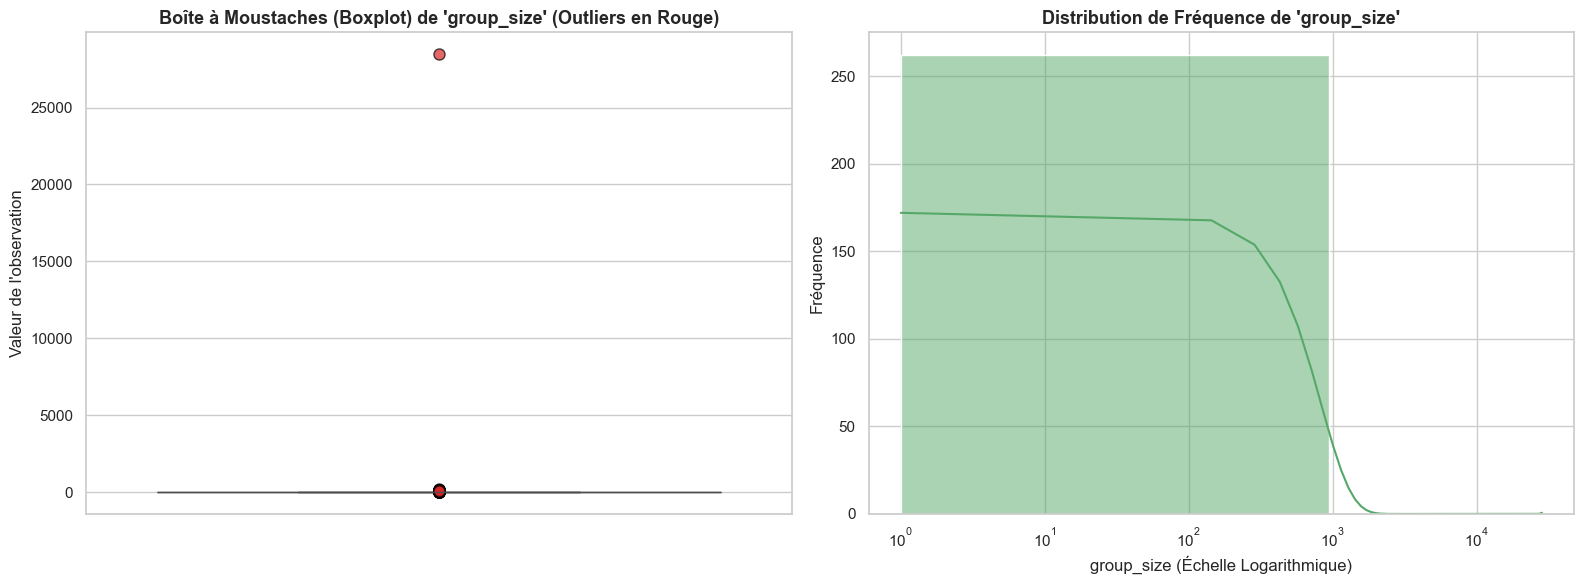


=== 45 OUTLIERS DETECTES (Dataset 2371) ===


,scientific_name,common_name,date_time,group_size,Outlier_Type,Reason
190,Megaptera novaeangliae,Humpback whale,2025-07-09 17:37:00,28465,Statistique (IQR),Supérieur au seuil statistique IQR (22.2 indiv...
0,Megaptera novaeangliae,Humpback whale,2025-07-09 17:37:00,28465,Biologique (Baleine),Taille de groupe irréaliste pour un grand céta...
17,Delphinus delphis,Short-beaked common dolphin,2025-08-06 17:26:00,170,Statistique (IQR),Supérieur au seuil statistique IQR (22.2 indiv...
255,Delphinus delphis,Short-beaked common dolphin,2025-07-30 16:51:00,160,Statistique (IQR),Supérieur au seuil statistique IQR (22.2 indiv...
34,Tursiops truncatus,Common bottlenose dolphin,2025-07-02 17:38:00,150,Statistique (IQR),Supérieur au seuil statistique IQR (22.2 indiv...
222,Delphinus delphis,Short-beaked common dolphin,2025-07-16 17:10:00,150,Statistique (IQR),Supérieur au seuil statistique IQR (22.2 indiv...
232,Delphinus delphis,Short-beaked common dolphin,2025-07-20 16:23:00,150,Statistique (IQR),Supérieur au seuil statistique IQR (22.2 indiv...
116,Delphinus delphis,Short-beaked common dolphin,2025-08-27 17:01:00,105,Statistique (IQR),Supérieur au seuil statistique IQR (22.2 indiv...
231,Delphinus delphis,Short-beaked common dolphin,2025-07-20 15:48:00,100,Statistique (IQR),Supérieur au seuil statistique IQR (22.2 indiv...
247,Tursiops truncatus,Common bottlenose dolphin,2025-07-28 10:59:00,85,Statistique (IQR),Supérieur au seuil statistique IQR (22.2 indiv...


In [9]:
DATASET_ID = "2371"  # Modifier cette valeur pour un autre dataset

df_raw, col_name = load_dataset(DATASET_ID)
if df_raw is not None and col_name is not None:
    df_outliers, stats_bounds = detect_outliers(df_raw, col_name)
    plot_distribution_and_outliers(df_raw, col_name, df_outliers, stats_bounds)
    
    if not df_outliers.empty:
        print(f"\n=== {len(df_outliers)} OUTLIERS DETECTES (Dataset {DATASET_ID}) ===")
        cols_show = ['scientific_name', 'common_name', 'date_time', col_name, 'Outlier_Type', 'Reason']
        cols_show = [c for c in cols_show if c in df_outliers.columns]
        display(df_outliers[cols_show].sort_values(by=col_name, ascending=False))
    else:
        print("\nAucun outlier détecté pour ce jeu de données.")

# 4. Recherche Globale et Boîte à Moustaches Multi-Datasets

Cette section compile l'intégralité des observations de tous les jeux de données d'un seul coup. 
Elle affiche :
1. **Le tableau complet contenant TOUTES les anomalies détectées** dans l'ensemble des jeux de données.
2. **Sous ce tableau, un graphique boîte à moustaches (boxplot) global** compilant toutes les observations de tous les différents datasets afin de visualiser les outliers à l'échelle du projet.

Lancement de la compilation globale sur 201 datasets...

Compilation terminée !
Nombre total d'anomalies détectées : 21

=== TABLEAU DE TOUTES LES ANOMALIES DETECTEES ===


,Dataset ID,Titre Dataset,Espèce,Nom Commun,Date,Colonne,Valeur,Type d'Anomalie,Description
8,2371,CRESLI marine mammal observations from whale w...,Megaptera novaeangliae,Humpback whale,2025-07-09 17:37:00,group_size,28465.0,Biologique (Grand cétacé),Effectif >= 50 pour baleine (28465 ind.)
19,2403,Seabird observations in Marine Offshore Specie...,Charadriiformes,Shore Birds,2023-08-11 17:57:00,group_size,9999.0,Placeholder 9999,Code placeholder 9999
11,197,"SWFSC Marine Mammal Survey, MOPS 1988, Cruise ...",Delphinus delphis,Short-beaked Common Dolphin,1988-10-27 17:10:00,group_size,3538.0,Biologique (Extrême),Super-groupe exceptionnel (3538.0 ind.)
7,1695,Happywhale - Spinner dolphin in North Pacific ...,Stenella longirostris,Spinner Dolphin,2017-02-09 10:19:01,individual_count,3500.0,Biologique (Extrême),Super-groupe exceptionnel (3500.0 ind.)
10,201,"SWFSC Marine Mammal Survey, MOPS 1989, Cruise ...",Delphinus delphis,Short-beaked Common Dolphin,1989-10-09 10:10:00,group_size,3100.0,Biologique (Extrême),Super-groupe exceptionnel (3100.0 ind.)
20,2403,Seabird observations in Marine Offshore Specie...,Branta hutchinsii,Cackling Goose,2024-04-24 13:09:00,group_size,3000.0,Biologique (Extrême),Super-groupe exceptionnel (3000.0 ind.)
17,2403,Seabird observations in Marine Offshore Specie...,Physeter macrocephalus,Sperm whale,2024-05-01 10:06:00,group_size,550.0,Biologique (Grand cétacé),Effectif >= 50 pour baleine (550.0 ind.)
18,2403,Seabird observations in Marine Offshore Specie...,Physeter macrocephalus,Sperm whale,2024-05-01 12:43:00,group_size,400.0,Biologique (Grand cétacé),Effectif >= 50 pour baleine (400.0 ind.)
16,2403,Seabird observations in Marine Offshore Specie...,Physeter macrocephalus,Sperm whale,2024-04-20 15:33:00,group_size,300.0,Biologique (Grand cétacé),Effectif >= 50 pour baleine (300.0 ind.)
0,1753,Happywhale - Fin whale in Southern Ocean,Balaenoptera physalus,Fin Whale,2023-02-25 15:30:56,individual_count,200.0,Biologique (Grand cétacé),Effectif >= 50 pour baleine (200.0 ind.)



=== GRAPH DE MOUSTACHE (BOXPLOT) DES VALEURS DE TOUTES LES DATASETS ===


C:\Users\ELECTRO FATAL\AppData\Local\Temp\ipykernel_24896\894859587.py:129: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all_values = pd.concat(all_raw_values, ignore_index=True)


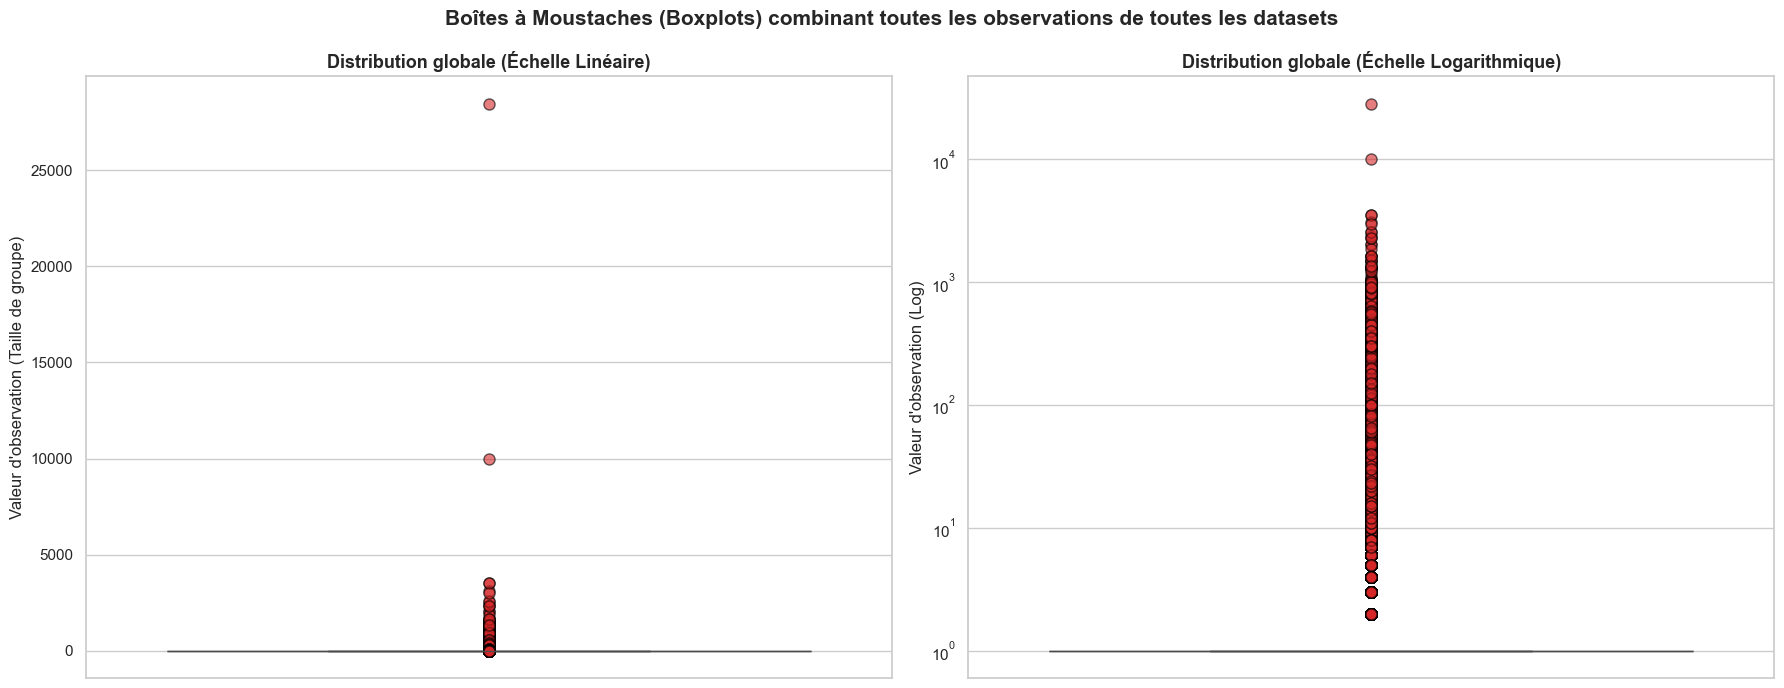

In [10]:
global_anomalies = []
all_raw_values = []

whales = {
    'megaptera novaeangliae', 'balaenoptera physalus', 'balaenoptera musculus',
    'balaenoptera acutorostrata', 'balaenoptera bonaerensis', 'balaenoptera borealis',
    'balaenoptera edeni', 'physeter macrocephalus', 'eubalaena glacialis',
    'eubalaena australis', 'eubalaena japonica', 'balaena mysticetus',
    'eschrichtius robustus'
}

if 'df_index' in locals():
    print(f"Lancement de la compilation globale sur {len(df_points_only)} datasets...")
    
    for idx, row in df_points_only.iterrows():
        ds_id = str(row['ID']).strip()
        fn = str(row['Dataset']).strip()
        title = row['Title']
        
        path = data_dir_local / fn
        if not path.exists():
            path = data_dir_remote / fn
            
        try:
            header = pd.read_csv(path, nrows=0)
            cols = [c.strip().lower() for c in header.columns]
            col_mapping = {c.strip().lower(): c for c in header.columns}
            
            target_col = None
            if 'individual_count' in cols:
                target_col = col_mapping['individual_count']
            elif 'size_group' in cols:
                target_col = col_mapping['size_group']
            elif 'group_size' in cols:
                target_col = col_mapping['group_size']
                
            if target_col is None:
                continue
                
            cols_to_load = [target_col]
            for opt_col in ['scientific_name', 'common_name', 'date_time']:
                if opt_col in header.columns:
                    cols_to_load.append(opt_col)
                    
            df_ds = pd.read_csv(path, usecols=cols_to_load, low_memory=False)
            # Application du parser pour gérer les plages comme "4-10"
            s = df_ds[target_col].apply(parse_group_size_val)
            df_ds['numeric_value'] = s
            
            # Collecter toutes les valeurs valides pour le boxplot global
            df_valid_ds = df_ds[s >= 0].dropna(subset=['numeric_value']).copy()
            df_valid_ds['dataset_id'] = ds_id
            all_raw_values.append(df_valid_ds[['dataset_id', 'numeric_value']])
            
            # Détection des anomalies
            ub = None
            if len(df_valid_ds) >= 4:
                q3 = df_valid_ds['numeric_value'].quantile(0.75)
                iqr = df_valid_ds['numeric_value'].quantile(0.75) - df_valid_ds['numeric_value'].quantile(0.25)
                ub = q3 + 1.5 * iqr
                
            for _, r in df_ds.iterrows():
                val = r['numeric_value']
                if pd.isna(val):
                    continue
                    
                is_anomaly = False
                reason = ""
                anom_type = ""
                
                if val < 0:
                    is_anomaly = True
                    anom_type = "Valeur Négative"
                    reason = f"Valeur négative ({val}) dans '{target_col}'"
                elif val == 9999:
                    is_anomaly = True
                    anom_type = "Placeholder 9999"
                    reason = "Code placeholder 9999"
                elif val >= 50:
                    sp = str(r.get('scientific_name', '')).strip().lower()
                    if any(w in sp for w in whales):
                        is_anomaly = True
                        anom_type = "Biologique (Grand cétacé)"
                        reason = f"Effectif >= 50 pour baleine ({val} ind.)"
                    elif 'ursus' in sp and val > 10:
                        is_anomaly = True
                        anom_type = "Biologique (Ours)"
                        reason = f"Effectif > 10 pour ours polaire ({val} ind.)"
                    elif val >= 3000:
                        is_anomaly = True
                        anom_type = "Biologique (Extrême)"
                        reason = f"Super-groupe exceptionnel ({val} ind.)"
                elif ub is not None and val > ub and val > 100:
                    is_anomaly = True
                    anom_type = "Statistique (IQR)"
                    reason = f"Outlier statistique significatif (> seuil local {ub:.1f})"
                    
                if is_anomaly:
                    global_anomalies.append({
                        'Dataset ID': ds_id,
                        'Titre Dataset': title,
                        'Espèce': r.get('scientific_name', 'Inconnu'),
                        'Nom Commun': r.get('common_name', 'Inconnu'),
                        'Date': r.get('date_time', 'Inconnu'),
                        'Colonne': target_col,
                        'Valeur': val,
                        'Type d\'Anomalie': anom_type,
                        'Description': reason
                    })
        except Exception as e:
            pass
            
    df_global_anomalies = pd.DataFrame(global_anomalies)
    print(f"\nCompilation terminée !")
    print(f"Nombre total d'anomalies détectées : {len(df_global_anomalies)}")
    
    # 1. AFFICHER TOUTES LES ANOMALIES (sans limitation head())
    print("\n=== TABLEAU DE TOUTES LES ANOMALIES DETECTEES ===")
    if not df_global_anomalies.empty:
        df_sorted_anom = df_global_anomalies.sort_values(by='Valeur', ascending=False)
        pd.set_option('display.max_rows', None)
        display(df_sorted_anom)
        pd.reset_option('display.max_rows')
    else:
        print("Aucune anomalie détectée.")
        
    # 2. AFFICHER LE GRAPH DE MOUSTACHE (BOXPLOT) GLOBALE DES VALEURS DE TOUS LES DATASETS COMBINES
    if all_raw_values:
        df_all_values = pd.concat(all_raw_values, ignore_index=True)
        
        print("\n=== GRAPH DE MOUSTACHE (BOXPLOT) DES VALEURS DE TOUTES LES DATASETS ===")
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        
        sns.boxplot(
            y=df_all_values['numeric_value'], 
            ax=axes[0], 
            color='#4C72B0',
            flierprops={'markerfacecolor': '#D62728', 'markeredgecolor': 'black', 'markersize': 8, 'alpha': 0.6}
        )
        axes[0].set_title("Distribution globale (Échelle Linéaire)", fontsize=13, fontweight='bold')
        axes[0].set_ylabel("Valeur d'observation (Taille de groupe)")
        
        sns.boxplot(
            y=df_all_values['numeric_value'], 
            ax=axes[1], 
            color='#55A868',
            flierprops={'markerfacecolor': '#D62728', 'markeredgecolor': 'black', 'markersize': 8, 'alpha': 0.6}
        )
        axes[1].set_yscale('log')
        axes[1].set_title("Distribution globale (Échelle Logarithmique)", fontsize=13, fontweight='bold')
        axes[1].set_ylabel("Valeur d'observation (Log)")
        
        plt.suptitle("Boîtes à Moustaches (Boxplots) combinant toutes les observations de toutes les datasets", fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune donnée disponible pour le graphique.")
else:
    print("L'index n'est pas disponible.")